Nessse notebook irei criar gráficos para realizar a analise final das respostas e compreender o resultado da pesquisa

In [27]:
# Importações das libs que vamos utilizar no notebook.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [28]:
# Criação das variaveis com os caminhos respectivos de cada pasta.
BASE_DIR = Path.cwd().parents[0]
DATA_FOLDER = BASE_DIR / "data"
PROCESSED_DIR = DATA_FOLDER / "processed"
PROCESSED_FILE = PROCESSED_DIR / "respostas_tratadas.csv"


In [29]:
# Criação de uma paleta de cores para os gráficos
charcoal = "#181818"
dark_gray = "#202020"
sky_blue = "#00A3E0"
teal = "#008D71"
red = "#FF0000"
gold = "#FFD700"
violet = "#BB86FC"
light_gray = "#E0E0E0"
medium_gray = "#444444"

color_palette = [sky_blue, teal, red, gold, violet]
text_color = light_gray

sns.set_theme(
    style="darkgrid",
    rc={
        "figure.facecolor": charcoal,
        "axes.facecolor": dark_gray,
        "axes.edgecolor": light_gray,
        "axes.labelcolor": light_gray,
        "xtick.color": light_gray,
        "ytick.color": light_gray,
        "text.color": light_gray,
        "grid.color": medium_gray,
        "axes.titlecolor": light_gray,
        "figure.autolayout": True,
    }
)

sns.set_palette(color_palette)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["savefig.facecolor"] = charcoal
plt.rcParams["savefig.edgecolor"] = charcoal
plt.rcParams["font.size"] = 11

In [31]:
# Importação do dataframe
df = pd.read_csv(PROCESSED_FILE)

Depois das configurações inciais, vamos seguir com analise. </br>
Primeiro ponto: analisar qual faixa etária foi predominante na pesquisa

# Faixa etária

Quantidade de participantes por faixa etária?

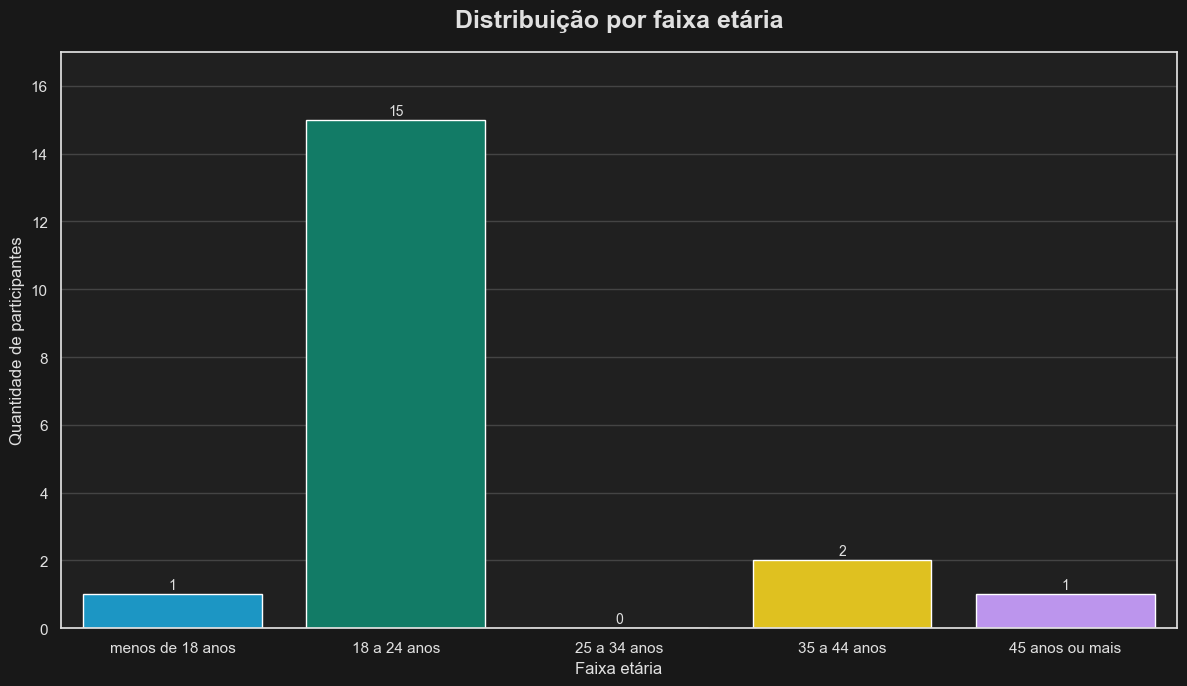

In [38]:
coluna_faixa = "faixa_etaria"

df[coluna_faixa] = (
    df[coluna_faixa]
    .astype(str)
    .str.strip()
    .str.lower()
)

ordem_faixas = [
    "menos de 18 anos",
    "18 a 24 anos",
    "25 a 34 anos",
    "35 a 44 anos",
    "45 anos ou mais"
]

faixa_counts = (
    df[coluna_faixa]
    .value_counts()
    .reindex(ordem_faixas, fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(
    x=faixa_counts.index,
    y=faixa_counts.values,
    ax=ax,
    hue=faixa_counts.index,
    legend=False
)

ax.set_title( "Distribuição por faixa etária",
    loc="center", fontsize=18,
    fontweight="bold", 
    pad=18)


ax.set_xlabel("Faixa etária")
ax.set_ylabel("Quantidade de participantes")
ax.set_ylim(0, faixa_counts.max() + 2)

for i, value in enumerate(faixa_counts.values):
    ax.text(
        i,
        value + 0.15,
        f"{int(value)}",
        ha="center",
        color=text_color,
        fontsize=10
    )

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Acesso à Internet

Percentual que tem acesso à internet?


In [42]:
contagem_internet = df["acesso_internet"].value_counts()
contagem_internet

acesso_internet
Sim    19
Name: count, dtype: int64

In [43]:
percentual_internet = (contagem_internet / contagem_internet.sum()) * 100
percentual_internet

acesso_internet
Sim    100.0
Name: count, dtype: float64

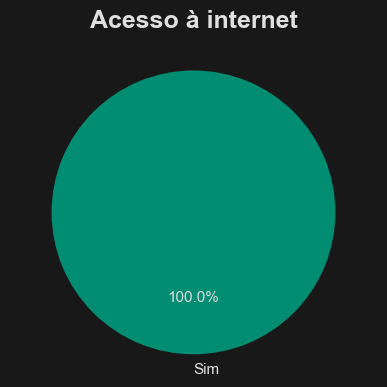

In [47]:
contagem_internet = df["acesso_internet"].value_counts()

fig, ax = plt.subplots(figsize=(4, 4))

ax.pie(
    contagem_internet.values,
    labels=contagem_internet.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=[teal],
    textprops={"color": text_color, "fontsize": 11},
    wedgeprops={"edgecolor": charcoal, "linewidth": 2}
)

ax.set_title(
    "Acesso à internet",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.axis("equal")
plt.tight_layout()
plt.show()

# Dispositivos de uso diário

Quantidade de participantes por tipo de dispositivo de uso diário?

In [33]:
dispositivos_dummies = df["dispositivos_uso"].str.get_dummies(sep=", ")
dispositivos_dummies.columns = dispositivos_dummies.columns.str.strip()

In [ ]:
contagem_dispositivos = dispositivos_dummies.sum().sort_values(ascending=False)
contagem_dispositivos



Celular / smartphone            17
Notebook / laptop                9
Computador de mesa (desktop)     7
Tablet                           3
Vídeo game (console)             2
dtype: int64

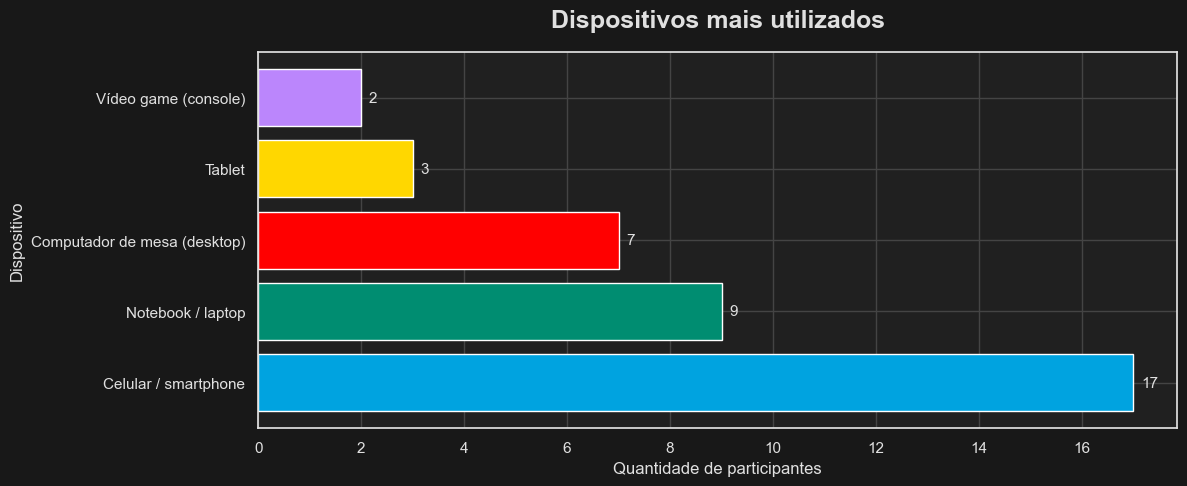

In [52]:
cores_barras = (color_palette * 10)[:len(contagem_dispositivos)]

fig, ax = plt.subplots(figsize=(12, 5))


ax.barh(
    contagem_dispositivos.index,
    contagem_dispositivos.values,
    color=cores_barras
)



ax.set_title( "Dispositivos mais utilizados",
    loc="center", fontsize=18,
    fontweight="bold", 
    pad=18)


ax.set_xlabel("Quantidade de participantes", loc="center")
ax.set_ylabel("Dispositivo")

ax.tick_params(axis="y", labelsize=11)
ax.tick_params(axis="x", labelsize=11)

for i, valor in enumerate(contagem_dispositivos.values):
    ax.text(
        valor + 0.15,
        i,
        str(int(valor)),
        va="center",
        ha="left",
        color=text_color,
        fontsize=11
    )

plt.tight_layout()
plt.show()

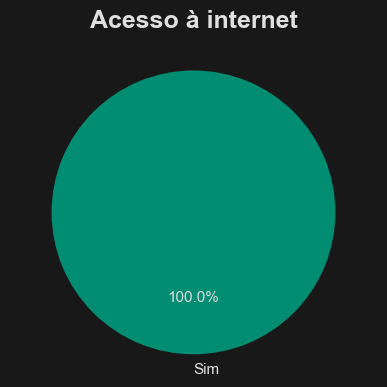

In [ ]:
contagem_internet = df["acesso_internet"].value_counts()

fig, ax = plt.subplots(figsize=(4, 4))

ax.pie(
    contagem_internet.values,
    labels=contagem_internet.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=[teal],
    textprops={"color": text_color, "fontsize": 11},
    wedgeprops={"edgecolor": charcoal, "linewidth": 2}
)

ax.set_title(
    "Acesso à internet",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.axis("equal")
plt.tight_layout()
plt.show()

# Dispositivos inteligente em casa

Quantidade de participantes por tipo de dispositivo inteligente?

In [48]:
disp_inteligentes_dummies = df["disp_inteligentes_casa"].str.get_dummies(sep=", ")
disp_inteligentes_dummies.columns = disp_inteligentes_dummies.columns.str.strip()

contagem_disp_inteligentes = (
    disp_inteligentes_dummies
    .sum()
    .sort_values(ascending=True)
)

contagem_disp_inteligentes

Tomadas inteligentes                     1
Não possuo dispositivos inteligentes     2
Google Nest)                             4
Caixa de som inteligente (ex: Alexa      4
Relógio inteligente (smartwatch)         8
Smart TV                                13
dtype: int64

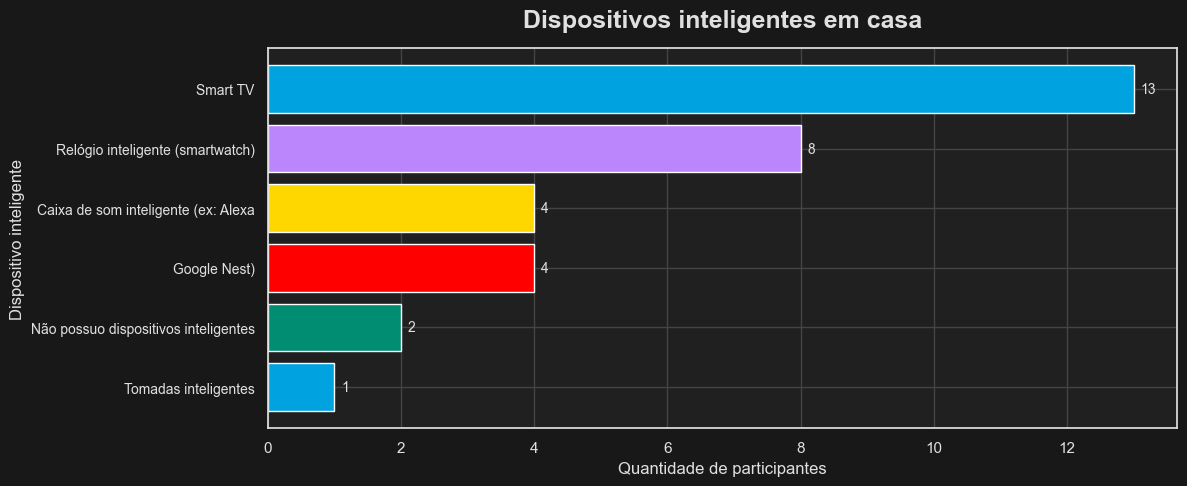

In [50]:
cores_barras = (color_palette * 10)[:len(contagem_disp_inteligentes)]

fig, ax = plt.subplots(figsize=(12, 5))

ax.barh(
    contagem_disp_inteligentes.index,
    contagem_disp_inteligentes.values,
    color=cores_barras
)

ax.set_title(
    "Dispositivos inteligentes em casa",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Quantidade de participantes")
ax.set_ylabel("Dispositivo inteligente")

ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=10)

for i, valor in enumerate(contagem_disp_inteligentes.values):
    ax.text(
        valor + 0.1,
        i,
        str(int(valor)),
        va="center",
        ha="left",
        color=text_color,
        fontsize=10
    )

plt.tight_layout()
plt.show()

# Conhecimento sobre IoT

Quantos participantes afirmam conhecer o conceito de IoT?

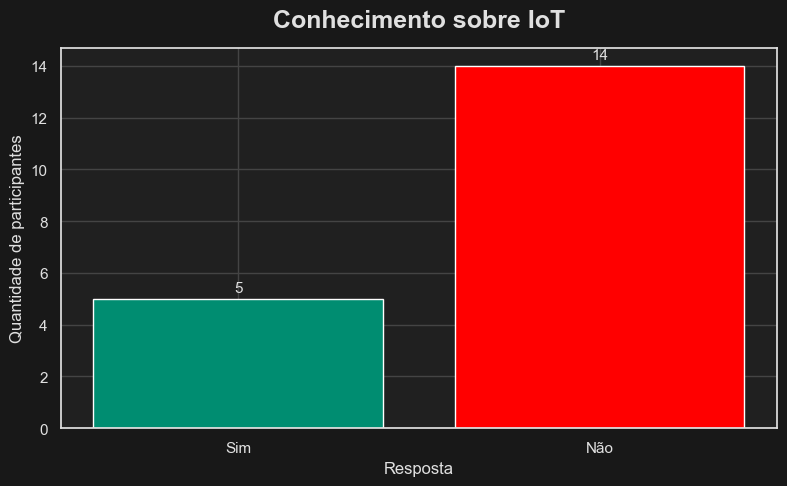

In [53]:
contagem_iot = df["conhece_iot"].value_counts()

ordem = ["Sim", "Não"]
contagem_iot = contagem_iot.reindex(ordem)

cores_iot = [teal, red]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    contagem_iot.index,
    contagem_iot.values,
    color=cores_iot
)

ax.set_title(
    "Conhecimento sobre IoT",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Resposta")
ax.set_ylabel("Quantidade de participantes")

ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)

for bar, valor in zip(bars, contagem_iot.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        valor + 0.15,
        str(int(valor)),
        ha="center",
        va="bottom",
        color=text_color,
        fontsize=11
    )

plt.tight_layout()
plt.show()

# Percepção de risco em dispositivos inteligentes

Quantos participantes percebem riscos de segurança associados ao uso de dispositivos inteligentes?

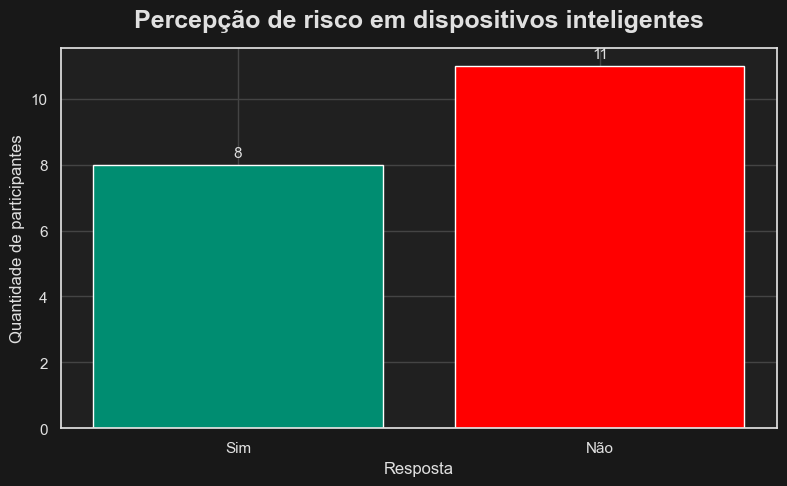

In [54]:
contagem_risco = df["risco_seguranca_disp"].value_counts()

ordem = ["Sim", "Não"]
contagem_risco = contagem_risco.reindex(ordem)

cores_risco = [teal, red]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    contagem_risco.index,
    contagem_risco.values,
    color=cores_risco
)

ax.set_title(
    "Percepção de risco em dispositivos inteligentes",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Resposta")
ax.set_ylabel("Quantidade de participantes")

ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)

for bar, valor in zip(bars, contagem_risco.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        valor + 0.15,
        str(int(valor)),
        ha="center",
        va="bottom",
        color=text_color,
        fontsize=11
    )

plt.tight_layout()
plt.show()

# Participação em cursos de tecnologia

Quantos participantes já fizeram algum curso de tecnologia?

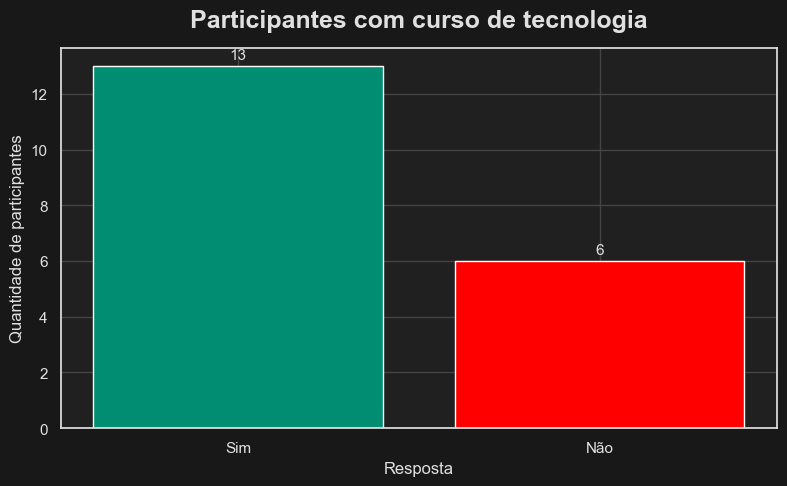

In [55]:
contagem_curso = df["curso_tecnologia"].value_counts()

ordem = ["Sim", "Não"]
contagem_curso = contagem_curso.reindex(ordem)

cores_curso = [teal, red]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    contagem_curso.index,
    contagem_curso.values,
    color=cores_curso
)

ax.set_title(
    "Participantes com curso de tecnologia",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Resposta")
ax.set_ylabel("Quantidade de participantes")

ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)

for bar, valor in zip(bars, contagem_curso.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        valor + 0.15,
        str(int(valor)),
        ha="center",
        va="bottom",
        color=text_color,
        fontsize=11
    )

plt.tight_layout()
plt.show()

# RESULTADO

Ao analisar as respostas, percebeu-se que a amostra é predominantemente composta por jovens de 18 a 24 anos, com poucos participantes em outras faixas etárias. Todos os respondentes declararam possuir acesso à internet, o que indica um nível básico de conectividade digital já consolidado entre os participantes. </br>

No uso de dispositivos no dia a dia, o celular/smartphone aparece como o equipamento mais presente, seguido por notebook/laptop e computador de mesa, enquanto tablet e videogame são menos frequentes. Em relação a dispositivos inteligentes em casa, a Smart TV se destaca como o principal recurso, acompanhada por relógios inteligentes e caixas de som inteligentes, enquanto poucos participantes disseram não possuir nenhum dispositivo inteligente.</br>

Quanto ao conhecimento sobre IoT, a maioria declarou não conhecer o conceito, mostrando uma lacuna entre o uso de tecnologia e a compreensão técnica sobre Internet das Coisas. Em relação à segurança, as opiniões ficaram relativamente equilibradas: parte dos participantes enxerga riscos em dispositivos inteligentes, enquanto outra parte não percebe esse problema com tanta clareza. Por outro lado, mais da metade dos respondentes afirma já ter feito algum curso de tecnologia, o que indica um interesse significativo em formação na área, mesmo que o conceito de IoT ainda não seja amplamente conhecido</br>